# 📊 EDA — Physics Problems Dataset
**EXACT 2026 Challenge — Dataset Type 2**

Notebook này thực hiện Exploratory Data Analysis (EDA) cho dataset vật lý của challenge EXACT 2026,
tập trung vào điện học và điện tĩnh. Mục tiêu là hiểu rõ cấu trúc dữ liệu, phân bố các loại bài toán,
các vấn đề data quality, và rút ra insights phục vụ thiết kế pipeline.

---
**Dataset:** `Physics_Problems_Text_Only.csv`  
**Columns:** `id`, `question`, `cot`, `answer`, `unit`

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')

# --- Style config ---
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})
PALETTE = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860','#DA8BC3','#8C8C8C','#CCB974']

data_path = Path.cwd().parent.parent / "data" / "raw" / "Physics_Problems_Text_Only.csv"
df = pd.read_csv(data_path)

df['prefix'] = df['id'].str.extract(r'^([A-Za-z]+)')
print(f'Loaded: {df.shape[0]} rows x {df.shape[1]} columns')
df.head(3)

Loaded: 1755 rows x 6 columns


,id,question,cot,answer,unit,prefix
0,TD401,Calculate the energy stored in capacitor C whe...,Step 1: Identify the given values for capacita...,45,J,TD
1,TD402,"Calculate the capacitance C of the capacitor, ...",Step 1: Identify the given values from the que...,100,μF,TD
2,LD001,"Two charges, q1 = 6 × 10^-8 C and q2 = -6 × 10...",Step 1: Identify the given charges and distanc...,0.05,N,LD


---
## 1. Cấu trúc cơ bản & Missing Values

In [3]:
print('=== SHAPE ===')
print(f'Rows: {len(df):,}   Cols: {len(df.columns)}')

print('\n=== DTYPES ===')
print(df.dtypes)

print('\n=== MISSING VALUES ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
print(pd.DataFrame({'count': missing, 'pct (%)': missing_pct}))

=== SHAPE ===
Rows: 1,755   Cols: 6

=== DTYPES ===
id          str
question    str
cot         str
answer      str
unit        str
prefix      str
dtype: object

=== MISSING VALUES ===
          count  pct (%)
id            0      0.0
question      1      0.1
cot           2      0.1
answer      401     22.8
unit        415     23.6
prefix        0      0.0


In [4]:
# Kiểm tra các bản ghi bị thiếu 'answer'
missing_answer_df = df[df['answer'].isnull()]
print(f"Tổng số bản ghi thiếu 'answer': {len(missing_answer_df)}")

print("\nMột vài bản ghi bị thiếu 'answer':")
display(missing_answer_df[['question', 'answer', 'unit']].head())

# Kiểm tra xem những bản ghi thiếu 'answer' có bị thiếu luôn 'unit' không
missing_both = missing_answer_df['unit'].isnull().sum()
print(f"\nSố bản ghi thiếu cả 'answer' và 'unit': {missing_both}")
if len(missing_answer_df) > 0:
    print(f"Tỷ lệ ({missing_both}/{len(missing_answer_df)}): {(missing_both / len(missing_answer_df) * 100):.1f}%")


Tổng số bản ghi thiếu 'answer': 401

Một vài bản ghi bị thiếu 'answer':


,question,answer,unit
1354,A motorboat travels downstream from A to B in ...,NaN,NaN
1355,A car travels from A to B at a speed of 56 km/...,NaN,NaN
1356,An object AB is placed in front of a diverging...,NaN,NaN
1357,An object has a mass of 5 kg. Calculate its po...,NaN,NaN
1358,An airplane with a mass of 1 ton is flying at ...,NaN,NaN



Số bản ghi thiếu cả 'answer' và 'unit': 401
Tỷ lệ (401/401): 100.0%


> Một số mẫu thiếu `đơn vị - unit` nhưng vẫn có `answer` vì câu trả lời không cần đơn vị.

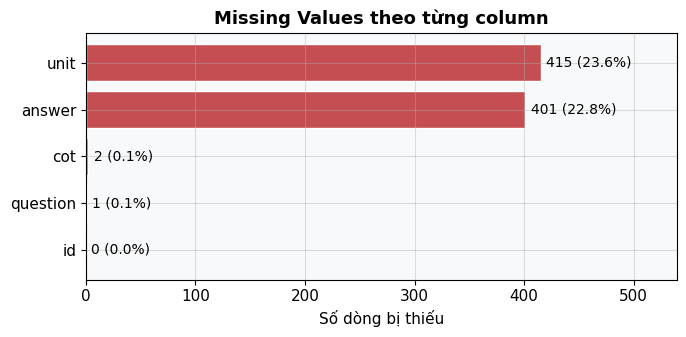

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.5))
cols = ['id', 'question', 'cot', 'answer', 'unit']
vals = [df[c].isnull().sum() for c in cols]
bars = ax.barh(cols, vals, color=['#4C72B0' if v == 0 else '#C44E52' for v in vals], edgecolor='white')
for bar, v in zip(bars, vals):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{v} ({v/len(df)*100:.1f}%)', va='center', fontsize=10)
ax.set_xlabel('Số dòng bị thiếu')
ax.set_title('Missing Values theo từng column')
ax.set_xlim(0, max(vals) * 1.3)
plt.tight_layout()
plt.show()

**Nhận xét:**  
- `answer` và `unit` thiếu 401 dòng (~22.8%) — toàn bộ thuộc prefix `QA`, rất có thể là **test set ẩn** được nhúng vào.
- `question` thiếu 1 dòng, `cot` thiếu 2 dòng — noise nhỏ, cần loại khi training.

---
## 2. Phân loại chủ đề theo ID Prefix

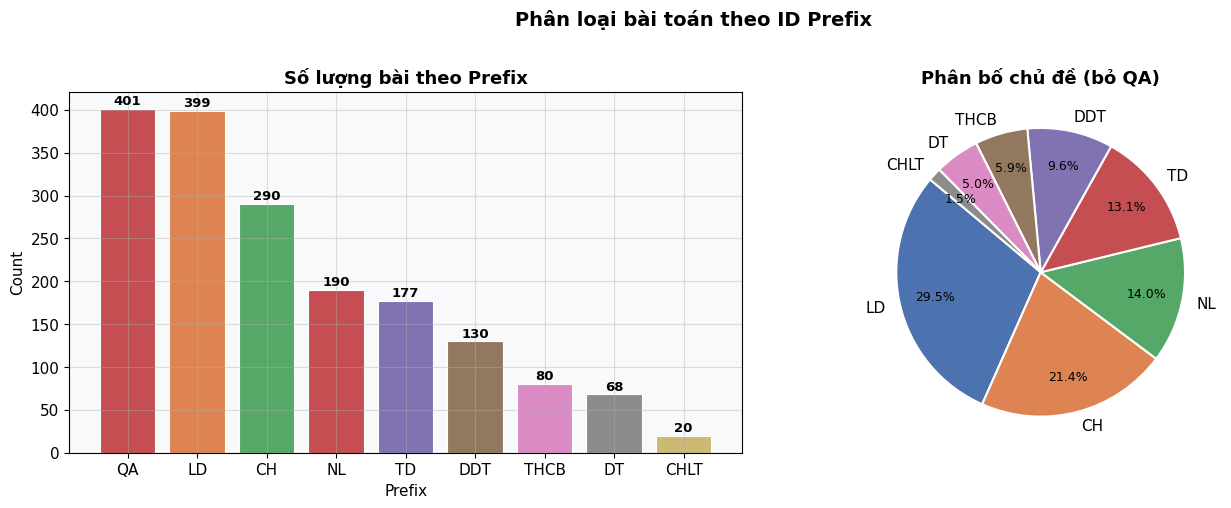


Mô tả các prefix:
  QA     (401 bài)  →  QA — Unlabeled / Possible Test
  LD     (399 bài)  →  LD — Lực điện (Coulomb)
  CH     (290 bài)  →  CH — Mạch RLC cơ bản
  NL     (190 bài)  →  NL — Năng lượng tụ điện
  TD     (177 bài)  →  TD — Tụ điện cơ bản
  DDT    (130 bài)  →  DDT — Điện từ / Solenoid
  THCB   ( 80 bài)  →  THCB — Sai số đo lường
  DT     ( 68 bài)  →  DT — Điện tích điểm
  CHLT   ( 20 bài)  →  CHLT — Mạch RLC nâng cao


In [6]:
PREFIX_DESC = {
    'QA'  : 'QA — Unlabeled / Possible Test',
    'LD'  : 'LD — Lực điện (Coulomb)',
    'CH'  : 'CH — Mạch RLC cơ bản',
    'NL'  : 'NL — Năng lượng tụ điện',
    'TD'  : 'TD — Tụ điện cơ bản',
    'DDT' : 'DDT — Điện từ / Solenoid',
    'THCB': 'THCB — Sai số đo lường',
    'DT'  : 'DT — Điện tích điểm',
    'CHLT': 'CHLT — Mạch RLC nâng cao',
}

prefix_counts = df['prefix'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#C44E52' if p == 'QA' else PALETTE[i % len(PALETTE)]
          for i, p in enumerate(prefix_counts.index)]
bars = axes[0].bar(prefix_counts.index, prefix_counts.values, color=colors, edgecolor='white', linewidth=0.8)
for bar, v in zip(bars, prefix_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(v), ha='center', fontsize=9.5, fontweight='bold')
axes[0].set_title('Số lượng bài theo Prefix')
axes[0].set_xlabel('Prefix')
axes[0].set_ylabel('Count')

# Pie chart (exclude QA to show real topic distribution)
no_qa = prefix_counts.drop('QA')
wedges, texts, autotexts = axes[1].pie(
    no_qa.values, labels=no_qa.index,
    autopct='%1.1f%%', colors=PALETTE[:len(no_qa)],
    startangle=140, pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for at in autotexts:
    at.set_fontsize(9)
axes[1].set_title('Phân bố chủ đề (bỏ QA)')

plt.suptitle('Phân loại bài toán theo ID Prefix', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\nMô tả các prefix:')
for p, desc in PREFIX_DESC.items():
    cnt = prefix_counts.get(p, 0)
    print(f'  {p:<6} ({cnt:>3} bài)  →  {desc}')

**Nhận xét:**  
- **LD** (Lực điện) chiếm đông nhất trong phần labeled — 399 bài (~29% non-QA).
- **CHLT** là nhóm nhỏ nhất (20 bài) nhưng lại **phức tạp nhất** (avg 8.8 bước CoT).
- **QA** (401 bài, đỏ) không có answer/unit và thuộc domain khác (cơ học, nhiệt học, quang học) — **cần xác nhận với BTC**.

---
## 3. Phân tích Answer — Kiểu dữ liệu & Dạng format

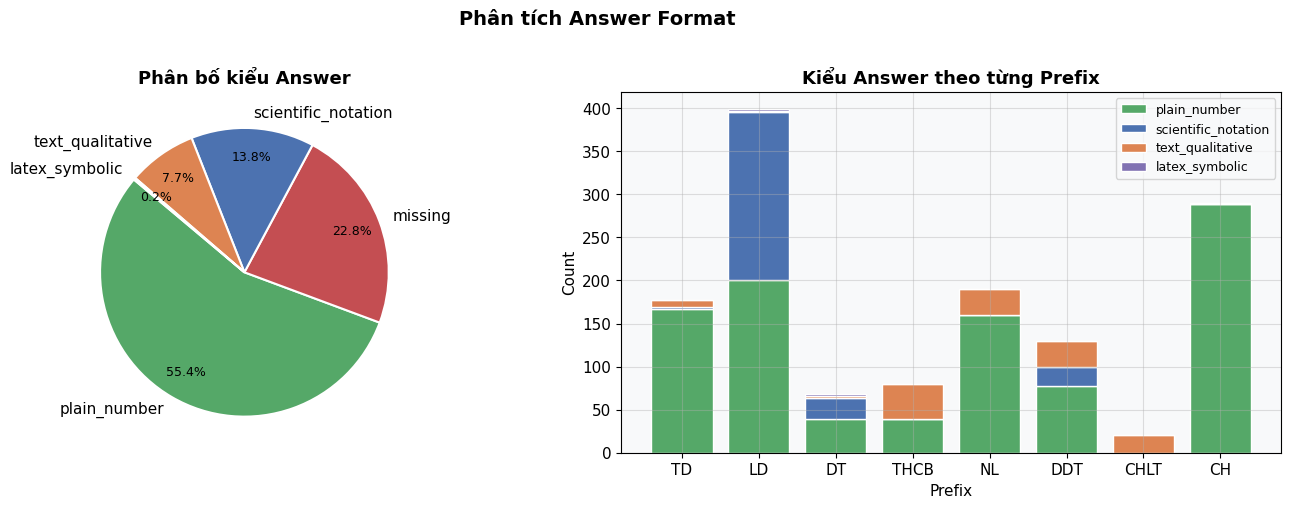

Chi tiết:
  plain_number          :  973 (55.4%)
  missing               :  401 (22.8%)
  scientific_notation   :  242 (13.8%)
  text_qualitative      :  135 (7.7%)
  latex_symbolic        :    4 (0.2%)


In [7]:
def classify_answer(a):
    if pd.isna(a):                                           return 'missing'
    s = str(a).strip()
    if re.match(r'^-?\d+\.?\d*$', s):                      return 'plain_number'
    if re.search(r'\^|×\s*10', s):                          return 'scientific_notation'
    if re.search(r'\\frac|\\sqrt|\\times|\^{', s):          return 'latex_symbolic'
    return 'text_qualitative'

df['ans_type'] = df['answer'].apply(classify_answer)
type_counts = df['ans_type'].value_counts()

type_colors = {
    'plain_number'       : '#55A868',
    'scientific_notation': '#4C72B0',
    'text_qualitative'   : '#DD8452',
    'latex_symbolic'     : '#8172B2',
    'missing'            : '#C44E52',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie
clrs = [type_colors[t] for t in type_counts.index]
wedges, texts, autotexts = axes[0].pie(
    type_counts.values, labels=type_counts.index,
    autopct='%1.1f%%', colors=clrs, startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5), pctdistance=0.8
)
for at in autotexts: at.set_fontsize(9)
axes[0].set_title('Phân bố kiểu Answer')

# Stacked bar per prefix
prefixes = [p for p in df['prefix'].unique() if p != 'QA']
type_order = ['plain_number','scientific_notation','text_qualitative','latex_symbolic']
data_matrix = pd.DataFrame(index=prefixes, columns=type_order, data=0)
for p in prefixes:
    sub = df[df['prefix'] == p]
    for t in type_order:
        data_matrix.loc[p, t] = (sub['ans_type'] == t).sum()

bottom = np.zeros(len(prefixes))
for t in type_order:
    vals = data_matrix[t].values.astype(float)
    axes[1].bar(prefixes, vals, bottom=bottom, label=t, color=type_colors[t], edgecolor='white')
    bottom += vals

axes[1].set_title('Kiểu Answer theo từng Prefix')
axes[1].set_xlabel('Prefix')
axes[1].set_ylabel('Count')
axes[1].legend(loc='upper right', fontsize=9)

plt.suptitle('Phân tích Answer Format', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Chi tiết:')
for t, cnt in type_counts.items():
    print(f'  {t:<22}: {cnt:>4} ({cnt/len(df)*100:.1f}%)')

In [8]:
print('=== SAMPLE: Scientific Notation ===')
sci = df[df['ans_type']=='scientific_notation'][['id','answer']].head(5)
print(sci.to_string(index=False))

print('\n=== SAMPLE: LaTeX Symbolic ===')
lat = df[df['ans_type']=='latex_symbolic'][['id','answer']]
print(lat.to_string(index=False))

print('\n=== SAMPLE: Text / Qualitative ===')
txt = df[df['ans_type']=='text_qualitative'][['id','prefix','answer']].head(8)
print(txt.to_string(index=False))

=== SAMPLE: Scientific Notation ===
   id             answer
LD002      24.45 × 10^-3
LD004      5.234 × 10^-3
LD005 9\sqrt{3} × 10^-27
LD006       1.23 × 10^-3
LD027      30.24 × 10^-3

=== SAMPLE: LaTeX Symbolic ===
   id                                answer
LD041                         \sqrt{2} × F₀
LD087                        -2\sqrt{2} x q
DT007                           a/ \sqrt{2}
DT047 1/2 . (1/ \sqrt{E_A} + 1/ \sqrt{E_B})

=== SAMPLE: Text / Qualitative ===
   id prefix           answer
LD047     LD Hướng về phía q₂
LD077     LD     E1 = (3/4)E2
TD015     TD             10/3
DT058     DT               8E
DT060     DT          1/4 \pi
TD369     TD    Do not change
TD373     TD              50%
TD374     TD             0; 0


**Nhận xét:**  
- **55.4% plain number** — dễ parse và verify bằng Python.
- **13.8% scientific notation** — cần normalize (`24.45 × 10^-3` → float) trước khi so sánh.
- **7.7% text/qualitative** — không thể so số, cần NLP evaluation (BLEU/semantic similarity).
- **~1% LaTeX symbolic** — trả về biểu thức đại số, cần SymPy để verify.
- **→ Pipeline phải có bước phân loại dạng answer** trước khi scoring.

---
## 4. Phân tích Unit

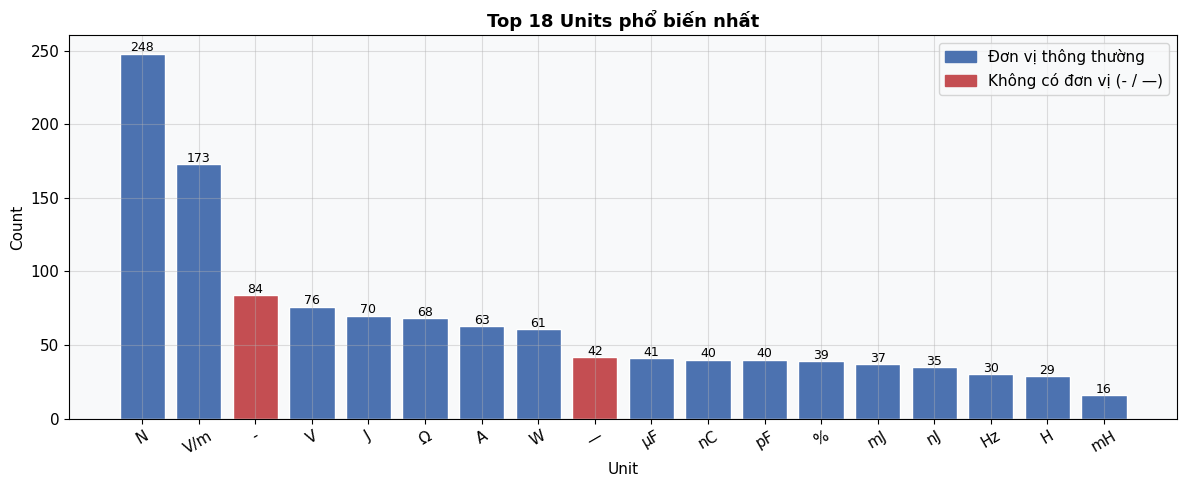

=== VẤN ĐỀ UNICODE: μF vs µF ===
  "μF" (hex bytes: cebc46)  →  41 dòng
  "pF" (hex bytes: 7046)  →  40 dòng
  "Hz" (hex bytes: 487a)  →  30 dòng
  "H" (hex bytes: 48)  →  29 dòng
  "mH" (hex bytes: 6d48)  →  16 dòng
  "µF" (hex bytes: c2b546)  →  14 dòng
  "nF" (hex bytes: 6e46)  →  1 dòng


In [9]:
unit_counts = df['unit'].value_counts().head(18)

fig, ax = plt.subplots(figsize=(12, 5))
colors_u = ['#C44E52' if u in ['-','—','nan'] else '#4C72B0' for u in unit_counts.index.astype(str)]
bars = ax.bar(unit_counts.index.astype(str), unit_counts.values, color=colors_u, edgecolor='white')
for bar, v in zip(bars, unit_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            str(v), ha='center', fontsize=9)
ax.set_title('Top 18 Units phổ biến nhất')
ax.set_xlabel('Unit')
ax.set_ylabel('Count')

red_patch = mpatches.Patch(color='#C44E52', label='Không có đơn vị (- / —)')
blue_patch = mpatches.Patch(color='#4C72B0', label='Đơn vị thông thường')
ax.legend(handles=[blue_patch, red_patch])
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Unicode inconsistency
print('=== VẤN ĐỀ UNICODE: μF vs µF ===')
uf_variants = df['unit'].value_counts()
for u in uf_variants.index:
    if 'F' in str(u) or 'H' in str(u):
        print(f'  "{u}" (hex bytes: {str(u).encode().hex()})  →  {uf_variants[u]} dòng')

**Nhận xét:**
- **N** (Newton) là unit phổ biến nhất — chủ yếu từ bài tập lực điện (LD).
- **V/m** (cường độ điện trường) đứng thứ 2.
- Dấu `-` và `—` (84 + 42 dòng) = bài không có đơn vị → tỉ lệ, %, hệ số thuần túy.
- **`μF` vs `µF`**: hai ký tự khác nhau về Unicode nhưng cùng nghĩa → **phải normalize** trước khi match.

---
## 5. Phân tích độ dài Question & CoT

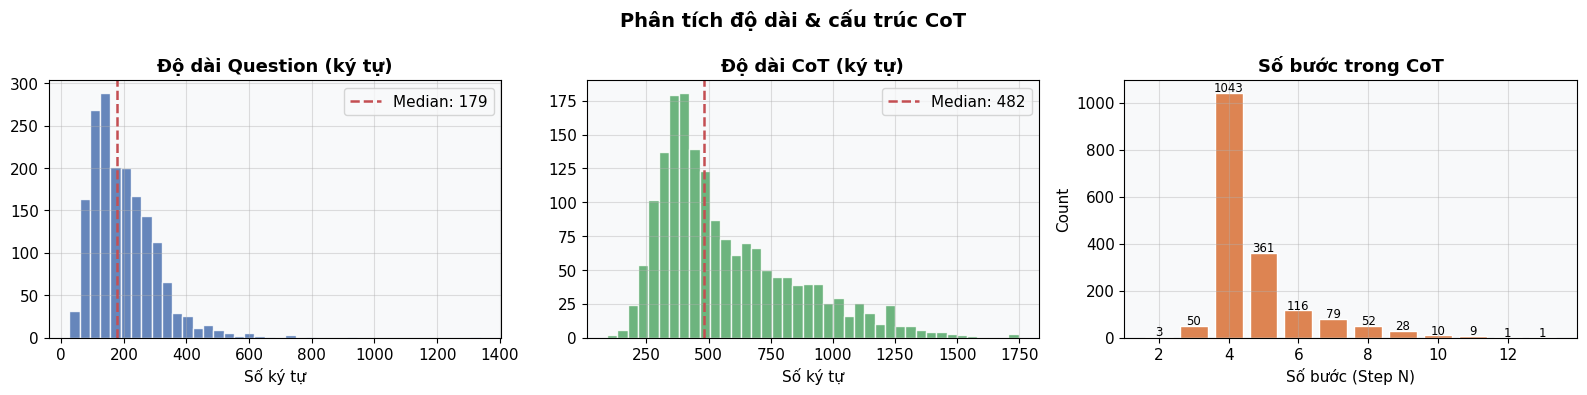

Question length stats:
count    1754.0
mean      198.1
std       106.2
min        26.0
25%       121.0
50%       179.0
75%       254.0
max      1339.0
Name: q_len, dtype: float64

CoT length stats:
count    1753.0
mean      570.4
std       277.1
min        92.0
25%       369.0
50%       482.0
75%       721.0
max      1747.0
Name: cot_len, dtype: float64


In [10]:
df['q_len']   = df['question'].str.len()
df['cot_len'] = df['cot'].str.len()
df['n_steps'] = df['cot'].str.count(r'Step \d+')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Question length
axes[0].hist(df['q_len'].dropna(), bins=40, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0].axvline(df['q_len'].median(), color='#C44E52', linestyle='--', lw=1.8, label=f'Median: {df["q_len"].median():.0f}')
axes[0].set_title('Độ dài Question (ký tự)')
axes[0].set_xlabel('Số ký tự')
axes[0].legend()

# CoT length
axes[1].hist(df['cot_len'].dropna(), bins=40, color='#55A868', edgecolor='white', alpha=0.85)
axes[1].axvline(df['cot_len'].median(), color='#C44E52', linestyle='--', lw=1.8, label=f'Median: {df["cot_len"].median():.0f}')
axes[1].set_title('Độ dài CoT (ký tự)')
axes[1].set_xlabel('Số ký tự')
axes[1].legend()

# Steps distribution
step_counts = df['n_steps'].value_counts().sort_index().dropna()
axes[2].bar(step_counts.index.astype(int), step_counts.values, color='#DD8452', edgecolor='white')
for x, y in zip(step_counts.index.astype(int), step_counts.values):
    axes[2].text(x, y + 5, str(y), ha='center', fontsize=8.5)
axes[2].set_title('Số bước trong CoT')
axes[2].set_xlabel('Số bước (Step N)')
axes[2].set_ylabel('Count')

plt.suptitle('Phân tích độ dài & cấu trúc CoT', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Question length stats:')
print(df['q_len'].describe().round(1))
print('\nCoT length stats:')
print(df['cot_len'].describe().round(1))

**Nhận xét:**
- Đa số câu hỏi dài **100–300 ký tự** — tương đối ngắn, phù hợp với LLM nhỏ.
- CoT trung bình **~570 ký tự**, phân bố rộng → bài phức tạp có CoT dài đáng kể.
- **4 bước CoT** chiếm đa số (1,043 bài) — cấu trúc nhất quán, tốt để dùng làm few-shot template.
- Có bài lên tới **13 bước** — multi-step phức tạp, cần pipeline chịu được reasoning dài.

---
## 6. Độ phức tạp theo từng Prefix

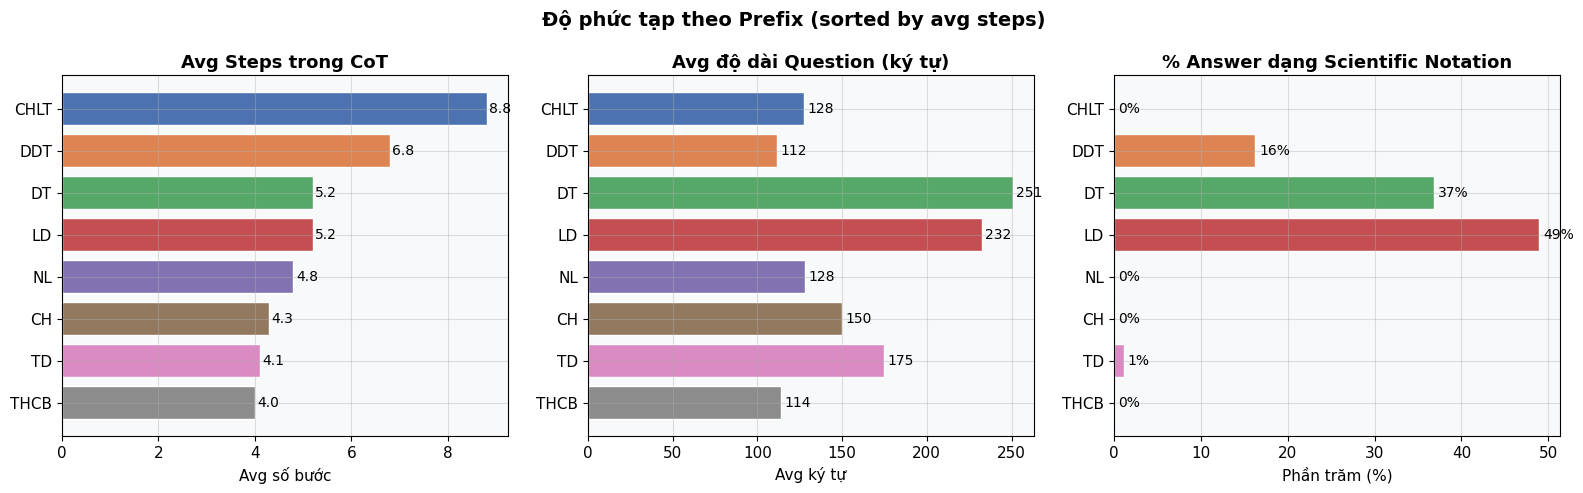

        count  avg_steps  avg_q_len  avg_cot_len  pct_sci
prefix                                                   
CHLT       20        8.8      127.6        794.2      0.0
DDT       130        6.8      111.6        792.6     16.2
DT         68        5.2      250.7        604.8     36.8
LD        399        5.2      232.4        731.4     48.9
NL        190        4.8      128.4        525.1      0.0
CH        290        4.3      150.2        519.6      0.0
TD        177        4.1      174.9        357.5      1.1
THCB       80        4.0      113.9        265.6      0.0


In [11]:
complexity = df[df['prefix'] != 'QA'].groupby('prefix').agg(
    count      = ('id', 'count'),
    avg_steps  = ('n_steps', 'mean'),
    avg_q_len  = ('q_len', 'mean'),
    avg_cot_len= ('cot_len', 'mean'),
    pct_sci    = ('answer', lambda x: x.str.contains(r'\^|×', na=False).mean() * 100)
).round(1).sort_values('avg_steps', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors_prefix = PALETTE[:len(complexity)]

# Avg steps
axes[0].barh(complexity.index, complexity['avg_steps'], color=colors_prefix, edgecolor='white')
for i, (v, p) in enumerate(zip(complexity['avg_steps'], complexity.index)):
    axes[0].text(v + 0.05, i, f'{v}', va='center', fontsize=10)
axes[0].set_title('Avg Steps trong CoT')
axes[0].set_xlabel('Avg số bước')
axes[0].invert_yaxis()

# Avg question length
axes[1].barh(complexity.index, complexity['avg_q_len'], color=colors_prefix, edgecolor='white')
for i, v in enumerate(complexity['avg_q_len']):
    axes[1].text(v + 2, i, f'{v:.0f}', va='center', fontsize=10)
axes[1].set_title('Avg độ dài Question (ký tự)')
axes[1].set_xlabel('Avg ký tự')
axes[1].invert_yaxis()

# Pct scientific notation
axes[2].barh(complexity.index, complexity['pct_sci'], color=colors_prefix, edgecolor='white')
for i, v in enumerate(complexity['pct_sci']):
    axes[2].text(v + 0.5, i, f'{v:.0f}%', va='center', fontsize=10)
axes[2].set_title('% Answer dạng Scientific Notation')
axes[2].set_xlabel('Phần trăm (%)')
axes[2].invert_yaxis()

plt.suptitle('Độ phức tạp theo Prefix (sorted by avg steps)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(complexity.to_string())

**Nhận xét:**
- **CHLT** khó nhất (8.8 bước) — RLC nâng cao với nhiều biến số phụ thuộc nhau.
- **DDT** (6.8 bước) — điện từ, cần tính toán vector và flux.
- **LD/DT** (5.2 bước) — lực điện, đề dài (~230–250 ký tự) nhưng có 37–49% answer dạng scientific → cần parser tốt.
- **NL/CH/TD/THCB** dễ nhất — formula ngắn, answer thường là số đơn giản.

---
## 7. Phân tích CoT — Chất lượng & Cấu trúc

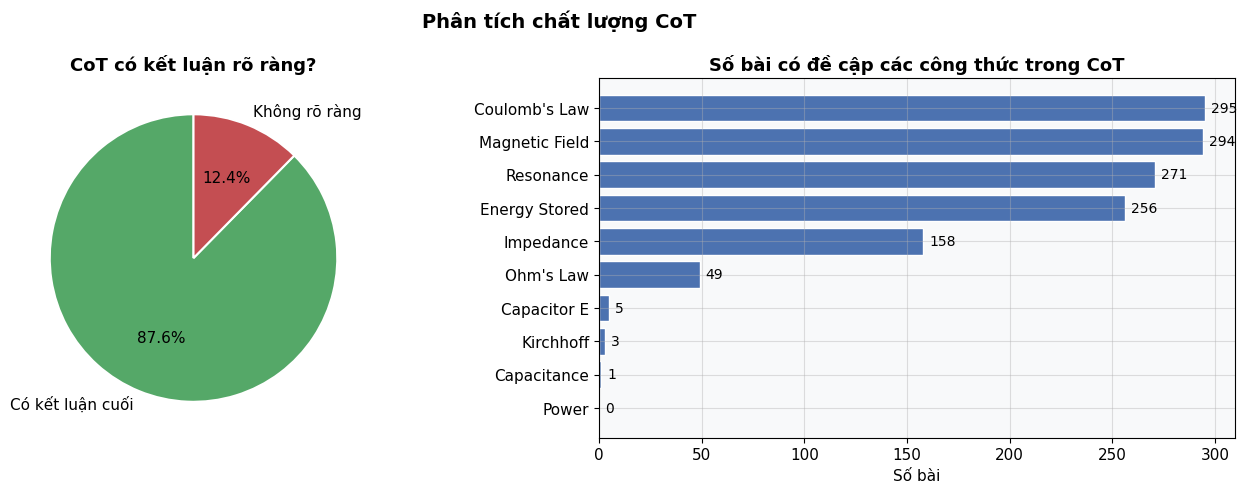

CoT có kết luận rõ ràng: 1538 / 1753 (87.6%)
CoT không rõ ràng: 217 bài — nên lọc khi dùng làm few-shot


In [12]:
# Does CoT end with a final answer?
def cot_has_ending(cot):
    if pd.isna(cot): return False
    tail = str(cot)[-200:].lower()
    return any(kw in tail for kw in ['result', 'answer', 'therefore', 'thus', 'final', '='])

df['cot_has_end'] = df['cot'].apply(cot_has_ending)

# Formula keywords in CoT
formulas = {
    "Coulomb's Law"  : r'coulomb|F\s*=\s*k',
    'Magnetic Field' : r'magnetic|B\s*=',
    'Energy Stored'  : r'W\s*=|energy.*stor',
    'Resonance'      : r'resonan|f\s*=\s*1\s*/\s*\(2.*pi',
    'Impedance'      : r'impedance|Z\s*=',
    'Ohm\'s Law'    : r'ohm|V\s*=\s*I\s*\*\s*R|U\s*=\s*I\s*R',
    'Capacitor E'    : r'E\s*=\s*0\.5\s*\*?\s*C',
    'Capacitance'    : r'C\s*=\s*Q\s*/\s*U',
    'Kirchhoff'      : r'kirchhoff|KVL|KCL',
    'Power'          : r'P\s*=\s*U\s*\*?\s*I|P\s*=\s*I\^2',
}

formula_counts = {}
for name, pat in formulas.items():
    formula_counts[name] = df['cot'].dropna().str.contains(pat, case=False, regex=True).sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CoT ending quality
end_vals = df['cot_has_end'].value_counts()
axes[0].pie(
    end_vals.values,
    labels=['Có kết luận cuối', 'Không rõ ràng'],
    autopct='%1.1f%%',
    colors=['#55A868','#C44E52'],
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
axes[0].set_title('CoT có kết luận rõ ràng?')

# Formula coverage
fc_sorted = dict(sorted(formula_counts.items(), key=lambda x: x[1], reverse=True))
axes[1].barh(list(fc_sorted.keys()), list(fc_sorted.values()), color='#4C72B0', edgecolor='white')
for i, v in enumerate(fc_sorted.values()):
    axes[1].text(v + 3, i, str(v), va='center', fontsize=10)
axes[1].set_title('Số bài có đề cập các công thức trong CoT')
axes[1].set_xlabel('Số bài')
axes[1].invert_yaxis()

plt.suptitle('Phân tích chất lượng CoT', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"CoT có kết luận rõ ràng: {df['cot_has_end'].sum()} / {df['cot'].notna().sum()} ({df['cot_has_end'].mean()*100:.1f}%)")
print(f"CoT không rõ ràng: {(~df['cot_has_end']).sum()} bài — nên lọc khi dùng làm few-shot")

**Nhận xét:**
- **87.7% CoT** có kết luận rõ ràng → tốt để dùng làm few-shot template.
- **217 CoT bị truncate** hoặc thiếu phần kết — cần filter ra khi chọn few-shot examples.
- Coulomb's Law và Magnetic Field là hai công thức xuất hiện nhiều nhất — nhất quán với phân bố prefix LD & DDT.

---
## 8. Multi-part Questions & Câu hỏi Symbolic

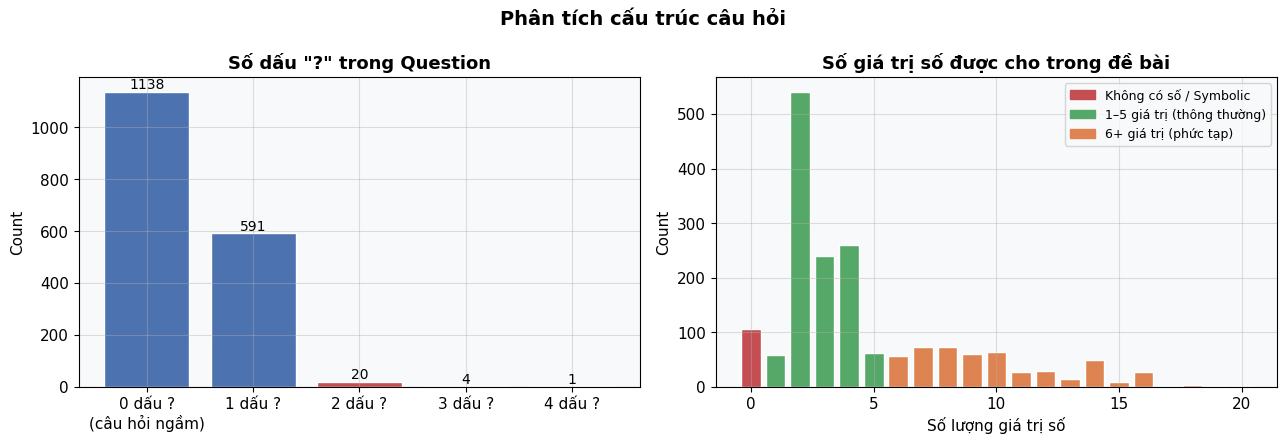

Multi-part questions (≥2 dấu ?): 25 bài
Câu hỏi 0 giá trị số (symbolic): 106 bài
Câu hỏi 6+ giá trị số (phức tạp): 489 bài


In [13]:
df['n_questions'] = df['question'].str.count(r'\?')
df['n_given']     = df['question'].apply(lambda x: len(re.findall(r'\d+\.?\d*', str(x))))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Multi-part questions
q_counts = df['n_questions'].value_counts().sort_index()
label_map = {0: '0 dấu ?\n(câu hỏi ngầm)', 1: '1 dấu ?', 2: '2 dấu ?', 3: '3 dấu ?', 4: '4 dấu ?'}
axes[0].bar(
    [label_map.get(i, str(i)) for i in q_counts.index],
    q_counts.values,
    color=['#C44E52' if i >= 2 else '#4C72B0' for i in q_counts.index],
    edgecolor='white'
)
for x, v in zip(range(len(q_counts)), q_counts.values):
    axes[0].text(x, v + 10, str(v), ha='center', fontsize=10)
axes[0].set_title('Số dấu "?" trong Question')
axes[0].set_ylabel('Count')

# Given values distribution
given_counts = df['n_given'].value_counts().sort_index()
given_counts = given_counts[given_counts.index <= 20]
colors_g = ['#C44E52' if i == 0 else '#55A868' if i <= 5 else '#DD8452'
            for i in given_counts.index]
axes[1].bar(given_counts.index, given_counts.values, color=colors_g, edgecolor='white')
axes[1].set_title('Số giá trị số được cho trong đề bài')
axes[1].set_xlabel('Số lượng giá trị số')
axes[1].set_ylabel('Count')

red_p   = mpatches.Patch(color='#C44E52', label='Không có số / Symbolic')
green_p = mpatches.Patch(color='#55A868', label='1–5 giá trị (thông thường)')
orange_p= mpatches.Patch(color='#DD8452', label='6+ giá trị (phức tạp)')
axes[1].legend(handles=[red_p, green_p, orange_p], fontsize=9)

plt.suptitle('Phân tích cấu trúc câu hỏi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Multi-part questions (≥2 dấu ?): {(df['n_questions'] >= 2).sum()} bài")
print(f"Câu hỏi 0 giá trị số (symbolic): {(df['n_given'] == 0).sum()} bài")
print(f"Câu hỏi 6+ giá trị số (phức tạp): {(df['n_given'] >= 6).sum()} bài")

In [27]:
for idx, row in df[df['n_questions'] > 1][['id', 'question', 'answer', 'n_questions']].iterrows():
    print("=" * 80)
    print(f"Index: {idx} | ID : {row['id']}| n_questions: {row['n_questions']}")
    
    print("\nQuestion:")
    print(row['question'])
    
    print("\nAnswer:")
    print(row['answer'])

Index: 1145 | ID : CH082| n_questions: 3.0

Question:
1. **"If L = 0.1 H, what capacitance C should be chosen to achieve resonance at f = 400 Hz?"**
2. **"Given L = 0.1 H, what value of capacitor C is needed to resonate at f = 400 Hz?"**
3. **"What capacitance C is required for resonance at f = 400 Hz, given an inductance L = 0.1 H?"**

Answer:
1.58
Index: 1350 | ID : CH377| n_questions: 2.0

Question:
Here are a few ways to translate that question, depending on desired conciseness and phrasing:
**Option 1 (Direct and common for physics problems):**
"At resonance, with U = 200 V and R = 25 Ω. What is the power P?"
**Option 2 (Slightly rephrased as a task):**
"Calculate the power P for a circuit at resonance, given U = 200 V and R = 25 Ω."
**Option 3 (More concise):**
"What is the power P at resonance, given U = 200 V and R = 25 Ω?"
All options convey the same meaning. The term "U" is sometimes used for voltage in English texts, but "V" is more common as the symbol for voltage (especial

**Nhận xét:**
- **25 bài multi-part** (≥2 câu hỏi trong 1 đề) — pipeline cần detect và trả lời từng phần.
- **106 bài không có giá trị số** → bài toán symbolic hoặc qualitative — cần xử lý riêng.
- Phần lớn bài có **2–5 giá trị số** — phù hợp với pipeline trích xuất → tính toán.

### Nhóm 1 — LLM Generation Artifacts (🗑️ DROP)

Đây là **lỗi data pipeline**, không phải bài toán thật. LLM được dùng để dịch/paraphrase câu hỏi nhưng trả về **nhiều phiên bản thay vì chọn một**.

| ID | Triệu chứng |
|---|---|
| **CH082** | 3 cách hỏi cùng 1 câu, bold markdown, có `Answer:` inline |
| **CH377** | "Here are a few ways to translate... Option 1, 2, 3..." — LLM không follow format |
| **QA3910** | Câu hỏi gốc là *"Cho em hỏi câu vật lí với ạ"* — LLM dịch thành 5 options |
| **QA4447** | *"Giải hộ e bài 10"* — LLM giải thích từng chữ thay vì dịch |
| **QA4505** | *"mng ơi giải hộ"* — LLM dịch kèm giải thích ngữ pháp tiếng Việt |

**→ Không có giá trị, filter bỏ hoàn toàn.**  
**Cách detect:** `question` chứa các pattern `"Here are a few ways"`, `"Option 1"`, `"Option 2"`, `"\*\*Option"`, `"following statements"` (LLM meta-language).

---

### Nhóm 2 — Real Multi-part Physics Questions, answer = nan (📦 Test Set)

Đây là **bài toán thật, có sub-questions a/b/c**, nhưng không có answer → thuộc tập QA (unlabeled).

| ID | Nội dung thực sự |
|---|---|
| **QA7997572** | Bài toán gặp nhau của xe máy và xe đạp → kinematics |
| **QA8001784** | Nhiệt lượng, đá tan → thermodynamics |
| **QA8002898** | Kim đồng hồ vuông góc → math/physics |
| **QA929, QA5465, QA1906** | Phương trình chuyển động 2 xe → kinematics |
| **QA848, QA891** | Lực Coulomb, điện tích → đây là điện học nhưng vẫn nan |

**→ Giữ lại, không xử lý gì thêm, đây nhiều khả năng là test set thật.**  
**Sub-questions a/b/c không phải bug** — chúng là cấu trúc bài toán bình thường.

---

### Nhóm 3 — Noise / Ambiguous Questions (🤔 Xem xét)

| ID | Vấn đề |
|---|---|
| **QA3898** | *"Bong bóng bay lên rồi vỡ"* — câu hỏi định tính, chỉ có 1 dấu `?` thật |
| **QA1906** | Câu hỏi hỏi ngược lại về điện trở song song — không rõ đáp án |
| **QA4804** | Học sinh hỏi tại sao, không phải bài toán tính toán |

**→ Qualitative / conceptual questions — không thể dùng SymPy, cần LLM pure reasoning.**

---

## ✅ Kết luận & Hành động

```
n_questions > 1
        │
        ├─▶ Chứa "Option 1/2", "Here are a few ways",
        │   "following statements", markdown bold (**)
        │         └─▶ 🗑️ DROP — LLM artifact
        │
        ├─▶ Chứa a), b), c) hoặc "Problem 1/2"
        │   + answer = nan
        │         └─▶ 📦 GIỮ — Test set, multi-part thật
        │
        └─▶ Chứa a), b), c)
            + answer = có giá trị
                  └─▶ ⚠️ GIỮ nhưng cần xử lý riêng
                        (answer chỉ cho phần cuối cùng?)
```

**Thực tế thì metric `n_questions` (đếm `?`) là proxy quá noisy** — không nên dùng để detect multi-part. Nên thay bằng:
1. Detect LLM artifact → regex trên `question` content
2. Detect multi-part thật → tìm pattern `a\)`, `b\)`, `c\)`, `1\.`, `2\.` ở đầu dòng

---
## 9. Data Quality Issues

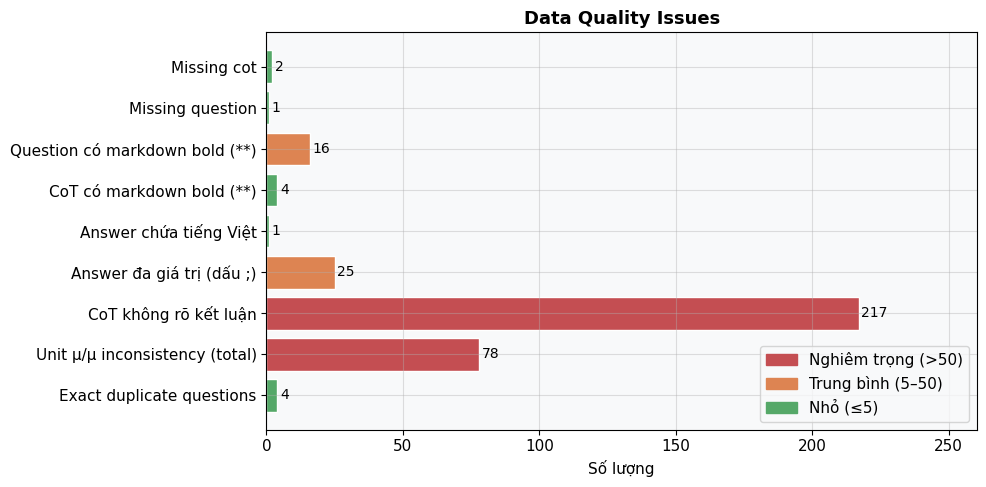

🟢  Exact duplicate questions: 4
🔴  Unit μ/µ inconsistency (total): 78
🔴  CoT không rõ kết luận: 217
🟡  Answer đa giá trị (dấu ;): 25
🟢  Answer chứa tiếng Việt: 1
🟢  CoT có markdown bold (**): 4
🟡  Question có markdown bold (**): 16
🟢  Missing question: 1
🟢  Missing cot: 2


In [38]:
issues = {}

# Exact duplicates
issues['Exact duplicate questions'] = df.duplicated(subset='question', keep=False).sum()

# Unicode inconsistency in unit
has_micro_u = df['unit'].str.contains('μ', na=False).sum()   # U+03BC
has_micro_mu= df['unit'].str.contains('µ', na=False).sum()   # U+00B5
issues['Unit μ/µ inconsistency (total)'] = has_micro_u + has_micro_mu

# CoT without clear ending
issues['CoT không rõ kết luận'] = (~df['cot_has_end']).sum()

# Multi-value answers (e.g. "0; 0", "36;12")
issues['Answer đa giá trị (dấu ;)'] = df['answer'].str.contains(';', na=False).sum()

# Answers in Vietnamese
issues['Answer chứa tiếng Việt'] = df['answer'].str.contains('Hướng|phía|tăng|giảm|sáng', na=False).sum()

# CoT has markdown bold (artifact of generation)
issues['CoT có markdown bold (**)'] = df['cot'].str.contains(r'\*\*', na=False).sum()
issues['Question có markdown bold (**)'] = df['question'].str.contains(r'\*\*', na=False).sum()

# Missing values
issues['Missing question'] = df['question'].isna().sum()
issues['Missing cot'] = df['cot'].isna().sum()

fig, ax = plt.subplots(figsize=(10, 5))
issue_names = list(issues.keys())
issue_vals  = list(issues.values())
severity_color = ['#C44E52' if v > 50 else '#DD8452' if v > 5 else '#55A868' for v in issue_vals]
bars = ax.barh(issue_names, issue_vals, color=severity_color, edgecolor='white')
for bar, v in zip(bars, issue_vals):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(v), va='center', fontsize=10)
ax.set_xlabel('Số lượng')
ax.set_title('Data Quality Issues')
ax.set_xlim(0, max(issue_vals) * 1.2)

red_p   = mpatches.Patch(color='#C44E52', label='Nghiêm trọng (>50)')
orange_p= mpatches.Patch(color='#DD8452', label='Trung bình (5–50)')
green_p = mpatches.Patch(color='#55A868', label='Nhỏ (≤5)')
ax.legend(handles=[red_p, orange_p, green_p], loc='lower right')
plt.tight_layout()
plt.show()

for name, val in issues.items():
    level = '🔴' if val > 50 else '🟡' if val > 5 else '🟢'
    print(f'{level}  {name}: {val}')

---
## 10. Phân tích riêng: QA Prefix

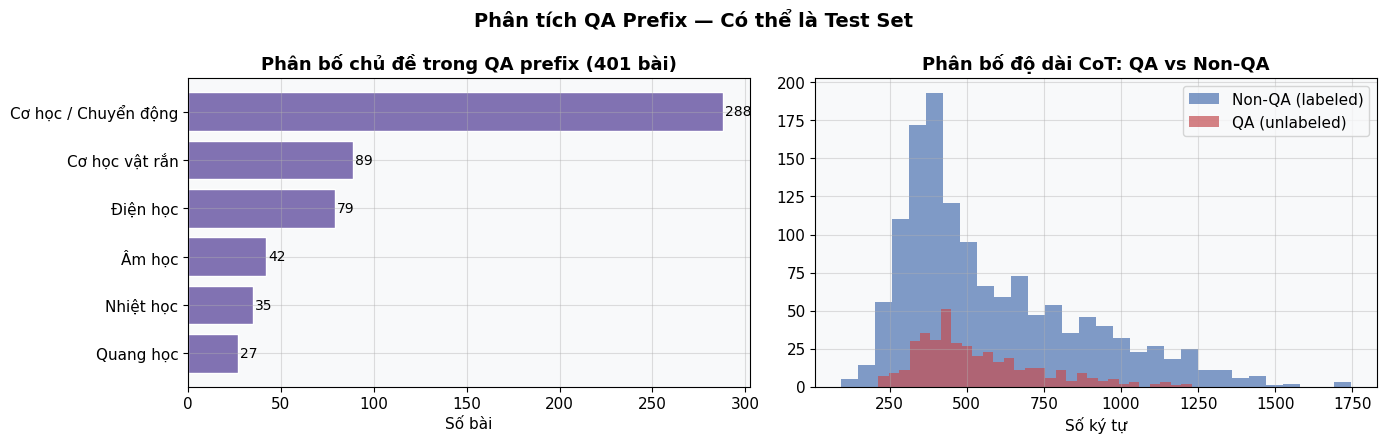

QA rows: 401 | Non-QA rows: 1354
QA có CoT: 401 / 401
QA có Answer: 0 / 401

QA CoT avg length: 535 chars
Non-QA CoT avg length: 581 chars


In [39]:
qa = df[df['prefix'] == 'QA'].copy()
non_qa = df[df['prefix'] != 'QA'].copy()

# Topic keywords in QA questions
topics = {
    'Cơ học / Chuyển động': r'velocity|speed|motion|distance|travel|km/h|m/s|accelerat',
    'Nhiệt học':            r'temperature|heat|thermal|ice|water|boiling|latent',
    'Quang học':            r'lens|focal|image|light|mirror|refract|optic',
    'Âm học':               r'sound|frequen|oscillat|vibrat|pitch|Hz|decibel',
    'Điện học':             r'current|voltage|resist|capacit|electric|circuit',
    'Cơ học vật rắn':       r'mass|weight|force|gravity|potential energy|kinetic',
}

qa_topics = {}
for topic, pat in topics.items():
    qa_topics[topic] = qa['question'].str.contains(pat, case=False, regex=True).sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# QA topic distribution
sorted_topics = dict(sorted(qa_topics.items(), key=lambda x: x[1], reverse=True))
axes[0].barh(list(sorted_topics.keys()), list(sorted_topics.values()),
             color='#8172B2', edgecolor='white')
for i, v in enumerate(sorted_topics.values()):
    axes[0].text(v + 1, i, str(v), va='center', fontsize=10)
axes[0].set_title('Phân bố chủ đề trong QA prefix (401 bài)')
axes[0].set_xlabel('Số bài')
axes[0].invert_yaxis()

# CoT length comparison: QA vs non-QA
axes[1].hist(non_qa['cot_len'].dropna(), bins=30, alpha=0.7, color='#4C72B0', label='Non-QA (labeled)')
axes[1].hist(qa['cot_len'].dropna(), bins=30, alpha=0.7, color='#C44E52', label='QA (unlabeled)')
axes[1].set_title('Phân bố độ dài CoT: QA vs Non-QA')
axes[1].set_xlabel('Số ký tự')
axes[1].legend()

plt.suptitle('Phân tích QA Prefix — Có thể là Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'QA rows: {len(qa)} | Non-QA rows: {len(non_qa)}')
print(f'QA có CoT: {qa["cot"].notna().sum()} / {len(qa)}')
print(f'QA có Answer: {qa["answer"].notna().sum()} / {len(qa)}')
print(f'\nQA CoT avg length: {qa["cot_len"].mean():.0f} chars')
print(f'Non-QA CoT avg length: {non_qa["cot_len"].mean():.0f} chars')

**Nhận xét về QA prefix:**  
- QA có CoT nhưng **không có answer/unit** → nhiều khả năng là **test set ẩn**.
- Nội dung đa dạng: cơ học, nhiệt học, quang học — **ngoài scope điện học** của phần còn lại.
- CoT của QA có độ dài tương đương non-QA → format nhất quán.
- **→ Cần xác nhận với BTC**: đây là unlabeled test hay out-of-domain augmentation?

---
## 11. Tổng kết & Implications cho Pipeline

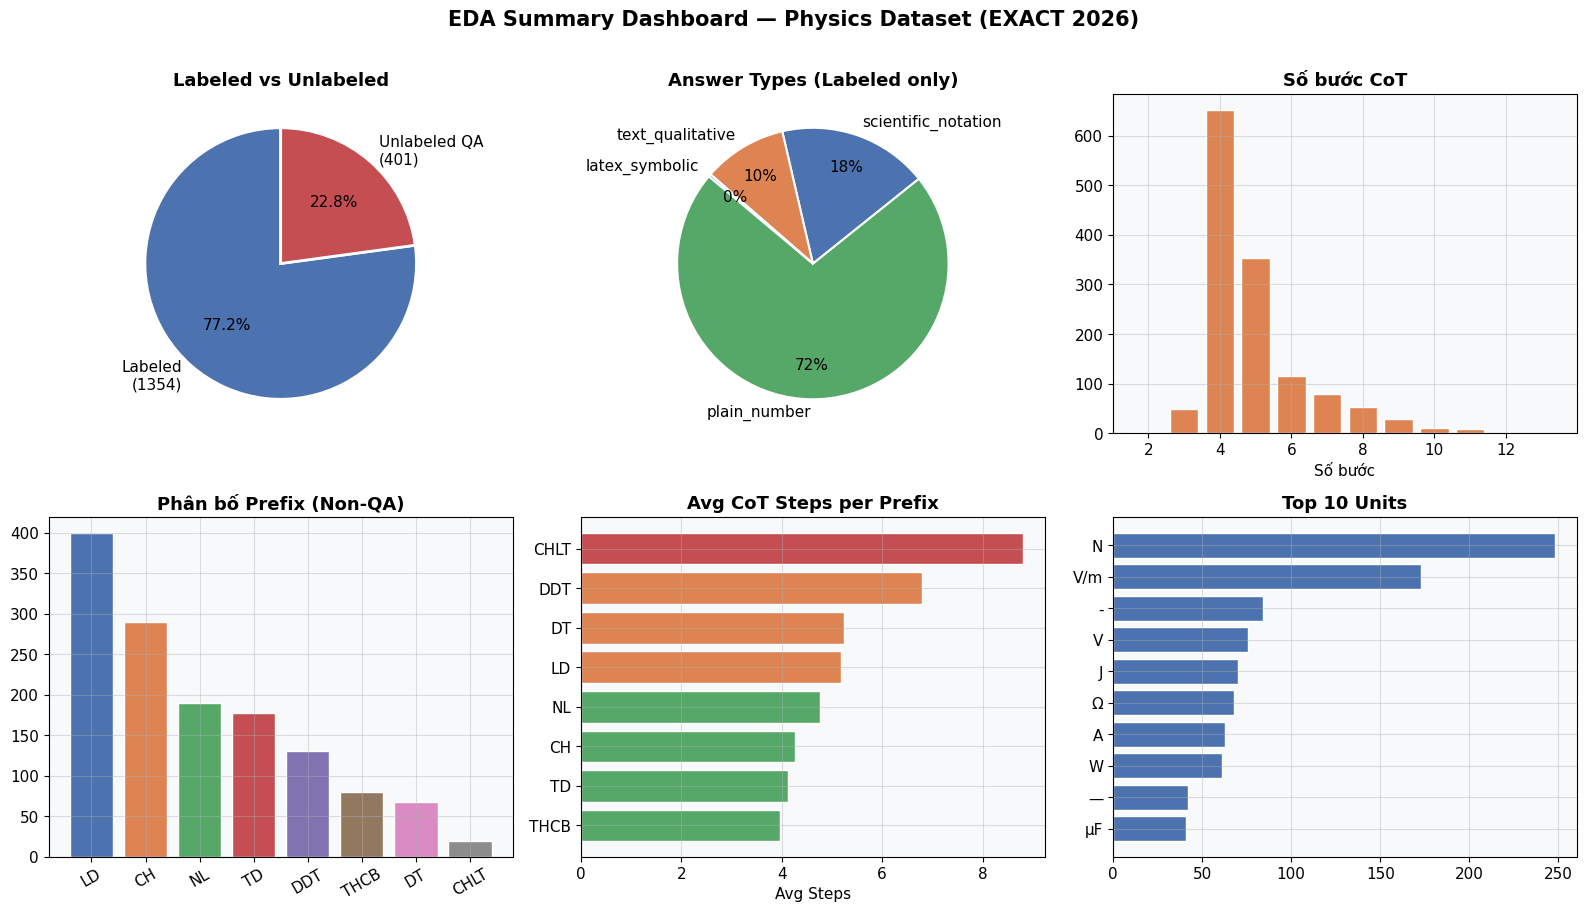

Dashboard saved to d:\Git\Exact_2026_Laplace-s_Red_Devils\app\figures\EDA_summary_Dataset_Physics.png


In [40]:
# Summary stats dashboard
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('EDA Summary Dashboard — Physics Dataset (EXACT 2026)', fontsize=15, fontweight='bold', y=1.01)

# 1. Labeled vs Unlabeled
axes[0,0].pie([len(non_qa), len(qa)],
              labels=[f'Labeled\n({len(non_qa)})', f'Unlabeled QA\n({len(qa)})'],
              colors=['#4C72B0','#C44E52'], autopct='%1.1f%%',
              wedgeprops=dict(edgecolor='white', linewidth=2), startangle=90)
axes[0,0].set_title('Labeled vs Unlabeled')

# 2. Answer type
at = df[df['prefix']!='QA']['ans_type'].value_counts()
axes[0,1].pie(at.values, labels=at.index,
              colors=[type_colors[t] for t in at.index],
              autopct='%1.0f%%', startangle=140,
              wedgeprops=dict(edgecolor='white', linewidth=1.5), pctdistance=0.75)
axes[0,1].set_title('Answer Types (Labeled only)')

# 3. Steps histogram
sc = df[df['prefix']!='QA']['n_steps'].value_counts().sort_index().dropna()
axes[0,2].bar(sc.index.astype(int), sc.values, color='#DD8452', edgecolor='white')
axes[0,2].set_title('Số bước CoT')
axes[0,2].set_xlabel('Số bước')

# 4. Prefix distribution (non-QA)
pc = non_qa['prefix'].value_counts()
axes[1,0].bar(pc.index, pc.values, color=PALETTE[:len(pc)], edgecolor='white')
axes[1,0].set_title('Phân bố Prefix (Non-QA)')
axes[1,0].tick_params(axis='x', rotation=30)

# 5. Avg steps per prefix
comp = non_qa.groupby('prefix')['n_steps'].mean().sort_values(ascending=True)
colors_bar = ['#C44E52' if v >= 7 else '#DD8452' if v >= 5 else '#55A868' for v in comp.values]
axes[1,1].barh(comp.index, comp.values, color=colors_bar, edgecolor='white')
axes[1,1].set_title('Avg CoT Steps per Prefix')
axes[1,1].set_xlabel('Avg Steps')

# 6. Unit top 10
uc = df[df['prefix']!='QA']['unit'].value_counts().head(10)
axes[1,2].barh(uc.index.astype(str), uc.values, color='#4C72B0', edgecolor='white')
axes[1,2].set_title('Top 10 Units')
axes[1,2].invert_yaxis()

plt.tight_layout()
fig_dir = Path.cwd().parent.parent / "figures" / "physics"
fig_dir.mkdir(parents=True, exist_ok=True)
fig_path = fig_dir / "EDA_summary_Dataset_Physics.png"
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Dashboard saved to {fig_path}')

---
## 📌 Kết luận & Recommendations cho Pipeline

### Những phát hiện chính

| # | Phát hiện | Impact |
|---|---|---|
| 1 | **401 dòng QA không có label** — có thể là test set ẩn hoặc out-of-domain | 🔴 Cao — cần xác nhận BTC |
| 2 | **4 dạng answer khác nhau** (plain, scientific, text, LaTeX) | 🔴 Cao — pipeline phải branch |
| 3 | **μF vs µF** — hai Unicode khác nhau | 🟡 Trung bình — normalize trước eval |
| 4 | **217 CoT không có kết luận rõ ràng** | 🟡 Trung bình — filter khi chọn few-shot |
| 5 | **25 bài multi-part** | 🟡 Trung bình — cần detect và split |
| 6 | **106 bài symbolic** (0 giá trị số) | 🟡 Trung bình — cần pipeline riêng |
| 7 | **4 exact duplicate questions** | 🟢 Thấp — deduplicate đơn giản |

### Đề xuất Pipeline

```
Input question
    │
    ├─▶ [Step 1] Detect dạng bài
    │       ├─ Numeric (có số, có unit)
    │       ├─ Symbolic (không số, ký hiệu a, q, R...)
    │       ├─ Qualitative (câu hỏi định tính)
    │       └─ Multi-part (có a/, b/, c/ hoặc nhiều dấu ?)
    │
    ├─▶ [Step 2] Extract given values + identify formula
    │       └─ SymPy / regex extractor
    │
    ├─▶ [Step 3] Solve
    │       ├─ Numeric: SymPy / Python calculator
    │       ├─ Symbolic: LLM với symbolic CoT template
    │       └─ Qualitative: LLM với rule-based reasoning
    │
    ├─▶ [Step 4] Normalize answer + unit
    │       └─ Unicode normalize, scientific notation → float
    │
    └─▶ [Step 5] Generate explanation
            └─ LLM sinh CoT theo template từ training data
```

### Few-shot Selection Strategy
- Chỉ dùng CoT có kết luận rõ ràng (`cot_has_end = True`): **1,538 bài**
- Chọn theo prefix để match với loại bài đang giải (per-prefix few-shot)
- CHLT & DDT cần few-shot dài hơn (avg 6–9 bước)